# Продажи автомобилей в Казахстане

Кислицын Дмитрий Геннадьевич, М26-555

Данные за январь — сентябрь 2019 года. Задача — очистить таблицу и сравнить «Меркур Авто» с рынком.

[Исходные данные](https://disk.yandex.ru/d/OmlexqoVSR6mwg). Для запуска нужны файлы `autokz2019.csv` и `clean_data.py` в одной папке с ноутбуком.

## 1. Загрузка данных

Проверю размер таблицы, типы, пропуски и дубликаты.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from clean_data import clean_data

%matplotlib inline
pd.set_option('display.max_columns', 18)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
plt.rcParams['figure.figsize'] = (8, 4)

raw = pd.read_csv('autokz2019.csv', sep=';', decimal=',', low_memory=False)
print('Размер исходной таблицы:', raw.shape)
display(raw.head(3))

Размер исходной таблицы: (39966, 25)


,Год,Месяц,Компания,Бренд,Модель,Модификация,Год выпуска,Страна-производитель,Вид топлива,...,Форма расчета,Количество,"Цена, USD","Продажа, USD",Область,Сегментация 2013,Класс 2013,Сегментация Eng,Локализация производства
0,2019,Май,Mercur Auto,Audi,A3,TFSI,2018,Германия,Бензин,...,безналичный,1.00,"28,115.00","28,115.00",г.Алматы,Легковые автомобили,C класс,C,Импорт
1,2019,Август,Mercur Auto,Audi,A3,TFSI,2018,Германия,Бензин,...,наличный,1.00,"32,246.99","32,246.99",г.Алматы,Легковые автомобили,C класс,C,Импорт
2,2019,Апрель,Mercur Auto,Audi,A4,TFSI,2018,Германия,Бензин,...,безналичный,1.00,"32,000.00","32,000.00",г.Алматы,Легковые автомобили,D класс,D,Импорт


In [2]:
inspection = pd.DataFrame({'Тип': raw.dtypes.astype(str), 'Пропуски': raw.isna().sum()})
display(inspection)
print('Полностью пустые строки:', raw.isna().all(axis=1).sum())
print('Полные дубликаты:', raw.duplicated().sum())

,Тип,Пропуски
Год,int64,0
Месяц,str,0
Компания,str,0
Бренд,str,0
Модель,str,0
Модификация,str,3591
Год выпуска,str,501
Страна-производитель,str,0
Вид топлива,str,3140
"Объём двиг, л,",str,4258


Полностью пустые строки: 0
Полные дубликаты: 18698


## 2. Очистка

Удаляю 18 698 полных дубликатов и семь столбцов из задания. Названия столбцов перевожу на английский. Привожу страны, топливо, привод и названия компаний к одному виду. Создаю дату на последний день месяца и меняю типы данных.

Исправляю сдвиг полей Renault и ошибочные объёмы двигателя. У электромобилей объём ДВС — ноль. Топливо заполняю только по однозначным совпадениям марки, модели и объёма. Остальные неизвестные характеристики оставляю пустыми.

Возврат и оптовые продажи сохраняю. Шесть пропусков количества при нулевой выручке заменяю на ноль. После удаления столбцов похожие строки повторно не удаляю.

In [3]:
df = clean_data('autokz2019.csv')
display(df.head(3))
display(pd.DataFrame({'Тип': df.dtypes.astype(str), 'Пропуски': df.isna().sum()}))

Исходные данные: 39966 строк, 25 столбцов


Удалено пустых строк: 0, полных дубликатов: 18698


Исправлено строк со сдвигом полей Renault: 27
Исправлен объём двигателя: Niva — 25, Polo — 1
Топливо восстановлено по однозначным аналогам: 38
Готовые данные: 21268 строк, 17 столбцов


,company,brand,model,manufacture_year,country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,revenue_usd,area,segment_2013,class_2013,sale_date
0,Меркур Авто,Audi,A3,2018,DEU,F,1.40,Автомат,FWD,Алматы,1,"28,115.00","28,115.00",г. Алматы,Легковые автомобили,C класс,2019-05-31
1,Меркур Авто,Audi,A3,2018,DEU,F,1.40,Автомат,FWD,Алматы,1,"32,246.99","32,246.99",г. Алматы,Легковые автомобили,C класс,2019-08-31
2,Меркур Авто,Audi,A4,2018,DEU,F,1.40,Автомат,FWD,Алматы,1,"32,000.00","32,000.00",г. Алматы,Легковые автомобили,D класс,2019-04-30


,Тип,Пропуски
company,str,0
brand,str,0
model,str,0
manufacture_year,Int64,233
country,str,0
fuel_type,category,1879
engine_volume,float64,2295
transmission,category,1889
drive_type,category,2294
region,str,0


### Проверка

Проверю даты, типы и выручку. Сохраню результат в CSV.

In [4]:
assert len(df) == len(raw.dropna(how='all').drop_duplicates())
assert df['sale_date'].dt.is_month_end.all()
assert df['quantity'].notna().all()
assert df['country'].str.fullmatch(r'[A-Z]{3}').all()
assert set(df['fuel_type'].dropna()) <= {'F', 'D', 'E', 'HYB'}
assert set(df['transmission'].dropna()) <= {'Автомат', 'Механика'}
assert set(df['drive_type'].dropna()) <= {'FWD', 'RWD', '4WD', '2WD'}
for column in ['fuel_type', 'transmission', 'drive_type', 'segment_2013', 'class_2013']:
    assert isinstance(df[column].dtype, pd.CategoricalDtype)
error = (df['revenue_usd'] - df['price_usd'] * df['quantity']).abs()
assert error.max() < 0.01
print('Максимальное расхождение выручки и цены × количества:', round(error.max(), 4), 'USD')
print('Диапазон дат:', df['sale_date'].min().date(), '—', df['sale_date'].max().date())
display(df.loc[df['quantity'] < 0, ['brand', 'model', 'quantity', 'revenue_usd']])
display(df.nlargest(5, 'quantity')[['brand', 'model', 'quantity', 'revenue_usd']])

df.to_csv('autokz2019_clean.csv', index=False, encoding='utf-8-sig', date_format='%Y-%m-%d')
reloaded = pd.read_csv('autokz2019_clean.csv', parse_dates=['sale_date'])
assert reloaded.shape == df.shape
assert reloaded['quantity'].sum() == df['quantity'].sum()
assert np.isclose(reloaded['revenue_usd'].sum(), df['revenue_usd'].sum())
print('CSV сохранён и повторно прочитан')

Максимальное расхождение выручки и цены × количества: 0.0007 USD
Диапазон дат: 2019-01-31 — 2019-09-30


,brand,model,quantity,revenue_usd
15144,Skoda,Superb,-1,"-35,588.25"


,brand,model,quantity,revenue_usd
8870,Lada,4x4,115,"1,035,000.00"
14974,Skoda,Octavia,100,"1,870,000.00"
20312,Volkswagen,Polo,79,"1,261,459.99"
7341,Jac,S3,70,"1,092,976.75"
8953,Lada,4x4,66,"594,000.00"


CSV сохранён и повторно прочитан

## 3. Анализ рынка

Экспорт исключаю из расчётов рынка. Продажи считаю по количеству машин с учётом возврата. Все суммы — в долларах США.

In [5]:
export = df[df['region'] == 'Экспорт']
market = df[df['region'] != 'Экспорт'].copy()
mercur = market[market['company'] == 'Меркур Авто'].copy()
sales = market[market['quantity'] > 0].copy()
print(f'Экспорт: {len(export)} строк, {export.quantity.sum():,} автомобилей, {export.revenue_usd.sum():,.2f} USD')
print(f'Внутренний рынок: {len(market)} строк, {market.quantity.sum():,} автомобилей, {market.revenue_usd.sum():,.2f} USD')
print(f'Продажи до вычета возврата: {sales.quantity.sum():,} автомобилей')

Экспорт: 331 строк, 440 автомобилей, 13,481,721.22 USD
Внутренний рынок: 20937 строк, 34,725 автомобилей, 801,697,865.97 USD
Продажи до вычета возврата: 34,726 автомобилей


### Цены и объём двигателя

В графике и таблице учитываю количество машин в каждой строке.

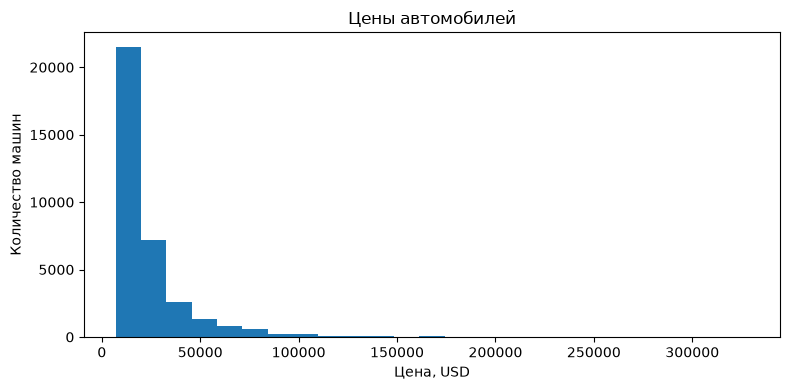

,Машины
engine_volume,
1.60,7250
2.00,4889
1.60,4782
2.70,2526
1.69,2472
2.50,1505
1.77,1178
2.69,840
2.40,703


Без сведений об объёме: 3322 машин


In [6]:
plt.hist(sales['price_usd'], bins=25, weights=sales['quantity'].astype(float))
plt.xlabel('Цена, USD')
plt.ylabel('Количество машин')
plt.title('Цены автомобилей')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

engine_sales = sales.dropna(subset=['engine_volume'])
display(engine_sales.groupby('engine_volume')['quantity'].sum().sort_values(ascending=False).head(10).to_frame('Машины'))
print('Без сведений об объёме:', sales.loc[sales.engine_volume.isna(), 'quantity'].sum(), 'машин')

Большинство машин стоит заметно меньше самых дорогих моделей. Большие двигатели встречаются у коммерческого транспорта.

In [7]:
years = sales.groupby('manufacture_year', dropna=False)['quantity'].sum()
display(years.to_frame('Машины'))

,Машины
manufacture_year,
2011,1
2013,1
2014,2
2016,29
2017,206
2018,7258
2019,26340
<NA>,889


### Бренды и модели

,Машины
brand,
Lada,11085
Hyundai,4987
Toyota,3636
Kia,2346
Nissan,1651
GAZ,1361
UAZ,1217
Renault,1193
Volkswagen,1048


Машины
brand      model         
Lada       Granta    3663
           Vesta     2650
           4x4       2469
           Largus    1682
Hyundai    Tucson    1370
           Accent    1246
Toyota     Camry     1120
Hyundai    Creta     1054
Kia        Rio        993
Volkswagen Polo       791

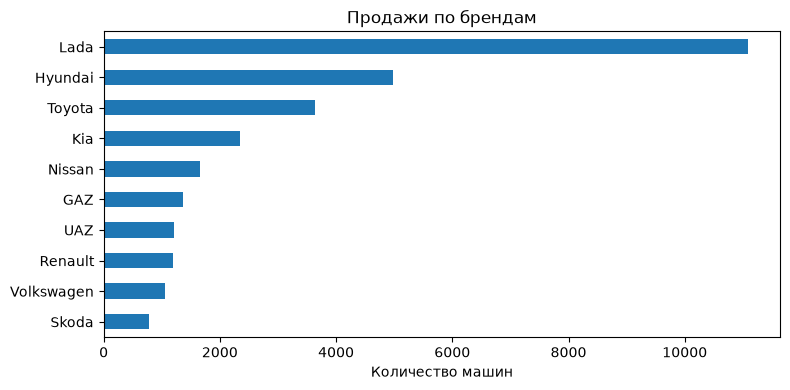

In [8]:
brand_sales = market.groupby('brand')['quantity'].sum().sort_values(ascending=False)
model_sales = market.groupby(['brand', 'model'])['quantity'].sum().sort_values(ascending=False)
display(brand_sales.head(10).to_frame('Машины'))
display(model_sales.head(10).to_frame('Машины'))
brand_sales.head(10).sort_values().plot.barh()
plt.xlabel('Количество машин')
plt.ylabel('')
plt.title('Продажи по брендам')
plt.tight_layout()
plt.show()

По продажам лидируют Lada, Hyundai и Toyota.

In [9]:
region_sales = market.groupby('region')['quantity'].sum().sort_values(ascending=False)
display(region_sales.head(10).to_frame('Машины'))

,Машины
region,
Алматы,7682
Нур-Султан,5682
Атырау,2503
Караганда,2355
Шымкент,2318
Костанай,2212
Усть-Каменогорск,1865
Уральск,1743
Актобе,1422


### Топливо и коробка передач

In [10]:
for column, name in [('fuel_type', 'Топливо'), ('transmission', 'Коробка передач')]:
    groups = market[column].astype('string').fillna('Неизвестно')
    table = market.groupby(groups)['quantity'].sum().sort_values(ascending=False)
    print(name)
    display(pd.DataFrame({'Машины': table, 'Доля, %': table / market.quantity.sum() * 100}))

Топливо


,Машины,"Доля, %"
fuel_type,,
F,30879,88.92
Неизвестно,2925,8.42
D,903,2.60
HYB,14,0.04
E,4,0.01


Коробка передач

,Машины,"Доля, %"
transmission,,
Автомат,17862,51.44
Механика,13904,40.04
Неизвестно,2959,8.52


Бензиновых машин больше всего. Среди известных коробок автоматических больше, чем механических.

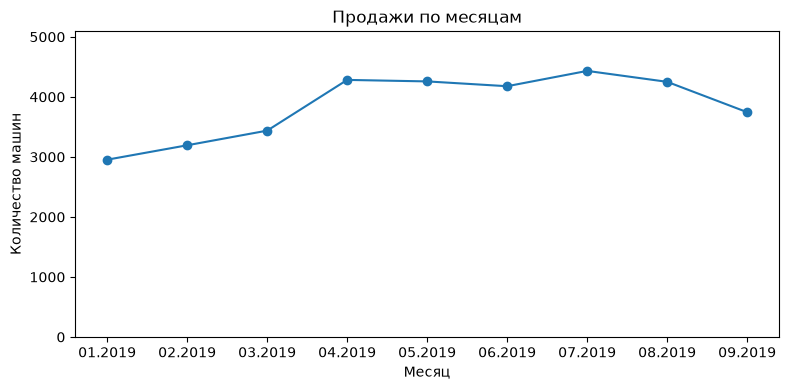

In [11]:
monthly = market.groupby('sale_date')['quantity'].sum()
plt.plot(monthly.index.strftime('%m.%Y'), monthly.values, marker='o')
plt.xlabel('Месяц')
plt.ylabel('Количество машин')
plt.title('Продажи по месяцам')
plt.ylim(0, monthly.max() * 1.15)
plt.tight_layout()
plt.show()

Больше всего машин продано в июле — 4 432. В сентябре продажи снизились. Данные охватывают только девять месяцев.

## 4. Меркур Авто

Средний чек считаю как выручку на автомобиль. Это не прибыль.

In [12]:
kpi = pd.DataFrame({
    'Рынок': [market.quantity.sum(), market.revenue_usd.sum(), market.revenue_usd.sum() / market.quantity.sum()],
    'Меркур Авто': [mercur.quantity.sum(), mercur.revenue_usd.sum(), mercur.revenue_usd.sum() / mercur.quantity.sum()],
}, index=['Автомобили с учётом возврата', 'Выручка, USD', 'Выручка на автомобиль, USD'])
display(kpi)
print('Доля по количеству:', round(mercur.quantity.sum() / market.quantity.sum() * 100, 2), '%')
print('Доля по выручке:', round(mercur.revenue_usd.sum() / market.revenue_usd.sum() * 100, 2), '%')
print('Превышение среднего чека рынка:', round((kpi.loc['Выручка на автомобиль, USD', 'Меркур Авто'] / kpi.loc['Выручка на автомобиль, USD', 'Рынок'] - 1) * 100, 2), '%')

,Рынок,Меркур Авто
Автомобили с учётом возврата,"34,725.00",394.00
"Выручка, USD","801,697,865.97","15,121,529.04"
"Выручка на автомобиль, USD","23,087.05","38,379.52"


Доля по количеству: 1.13 %
Доля по выручке: 1.89 %
Превышение среднего чека рынка: 66.24 %


### Доля по брендам и городам

Сравню продажи автоцентра с продажами соответствующего бренда или города. 100% относится к этой выборке.

In [13]:
def share_table(column):
    total = market.groupby(column, observed=True)['quantity'].sum()
    center = mercur.groupby(column, observed=True)['quantity'].sum()
    result = pd.DataFrame({'Рынок, авто': total, 'Меркур, авто': center}).fillna(0)
    result['Доля Меркур, %'] = result['Меркур, авто'] / result['Рынок, авто'] * 100
    result['В продажах Меркур, %'] = result['Меркур, авто'] / mercur.quantity.sum() * 100
    return result.sort_values('Меркур, авто', ascending=False)

display(share_table('brand').query('`Меркур, авто` > 0'))
display(share_table('region').query('`Меркур, авто` > 0'))

,"Рынок, авто","Меркур, авто","Доля Меркур, %","В продажах Меркур, %"
brand,,,,
Volkswagen,1048,294,28.05,74.62
Porsche,52,52,100.00,13.20
Audi,48,48,100.00,12.18


,"Рынок, авто","Меркур, авто","Доля Меркур, %","В продажах Меркур, %"
region,,,,
Алматы,7682,251,3.27,63.71
Нур-Султан,5682,51,0.90,12.94
Атырау,2503,43,1.72,10.91
Караганда,2355,21,0.89,5.33
Костанай,2212,14,0.63,3.55
Уральск,1743,14,0.80,3.55


### Доля по сегментам

In [14]:
display(share_table('segment_2013'))

,"Рынок, авто","Меркур, авто","Доля Меркур, %","В продажах Меркур, %"
segment_2013,,,,
Легковые автомобили,15008,234,1.56,59.39
Внедорожники,14047,145,1.03,36.80
Коммерческие автомобили,3487,8,0.23,2.03
Минивэны,1798,5,0.28,1.27
Пикапы,385,2,0.52,0.51


Легковые автомобили составляют 59% продаж «Меркур Авто», внедорожники — 37%. На рынке доля внедорожников — 40%.

## 5. Выводы

На внутреннем рынке продано 34 725 машин. «Меркур Авто» продал 394 машины: 1,13% рынка по количеству и 1,89% по выручке.

Средний чек автоцентра — 38 380 долларов, рынка — 23 087. Volkswagen даёт 75% продаж автоцентра, Алматы — 64%. Сильная сторона — более дорогой ассортимент. Слабая — зависимость от одного бренда и города. Можно проверить спрос на Volkswagen в других регионах.

В исходнике нет номеров продаж. Полные совпадения строк удалены по условию задания.

[Отчёт](report.md) · [Скрипт очистки](clean_data.py)